## Monster × VISTA Cross-Match (per HTM7 shard)

This notebook builds a **Monster–VISTA** reference catalog per **HTM7 shard** by attaching VISTA/VIDEO fluxes to Monster objects **while keeping Monster (Gaia-tied) astrometry**.

Matching strategy:
- Treat VIDEO positions as being at an effective VISTA epoch (here fixed to **2010.0** for DP1/CDFS tests).
- Propagate Monster coordinates to that epoch using Monster proper motions (PM-only).
- Match using **mutual nearest neighbour** within 0.5″ (**Gold**).
- Optionally require Monster-side isolation (2nd neighbour > 1″) (**Gold**).

Outputs:
- One FITS file per HTM7 shard in `outdir/`.
- Columns include VISTA fluxes.


### Imports

In [15]:
import os
import numpy as np
import astropy.units as u
from astropy.time import Time
import matplotlib.pyplot as plt
import lsst.afw.table as afwTable
from astropy.table import Table, hstack
from lsst.geom import SpherePoint, radians
from astropy.coordinates import SkyCoord, match_coordinates_sky

### HTM7 shard IDs and I/O configuration

In [16]:
# HTM7 shard IDs for DP1/CDFS region
htm7_ids = [
    147048, 147049, 147051, 147172, 147174, 147175,
    147028, 147042, 147050, 147052, 147053, 147055,
    147056, 147057, 147059, 147144, 147169, 147173,
    147180, 147182, 147183, 147188, 147190, 147191
]

# Input/output paths
monster_path_template = "data/the_monster_20250219/refcat_htm7_{id}.fits"
vista_file = "data/NIR-Catalogs/VISTA-VIDEO-CDFS-DR5.fits"
outdir = "data/video_cdfs/the_monster_20250219_vista"
os.makedirs(outdir, exist_ok=True)

# VISTA flux columns to extract
vista_cols = [
    "KS_FLUX_APER_3", "KS_FLUXERR_APER_3",
    "J_FLUX_APER_3",  "J_FLUXERR_APER_3",
    "H_FLUX_APER_3",  "H_FLUXERR_APER_3",
    "Y_FLUX_APER_3",  "Y_FLUXERR_APER_3",
    "Z_FLUX_APER_3",  "Z_FLUXERR_APER_3"
]

# Rename VISTA → LSST schema
vista_rename = {
    "KS_FLUX_APER_3": "ks_flux",  "KS_FLUXERR_APER_3": "ks_fluxErr",
    "J_FLUX_APER_3":  "j_flux",   "J_FLUXERR_APER_3":  "j_fluxErr",
    "H_FLUX_APER_3":  "h_flux",   "H_FLUXERR_APER_3":  "h_fluxErr",
    "Y_FLUX_APER_3":  "y2_flux",  "Y_FLUXERR_APER_3":  "y2_fluxErr",
    "Z_FLUX_APER_3":  "z2_flux",  "Z_FLUXERR_APER_3":  "z2_fluxErr",
}

# Monster → LSST renames (ComCam fluxes)
monster_rename = {
    "monster_ComCam_u_flux": "u_flux",
    "monster_ComCam_u_fluxErr": "u_fluxErr",
    "monster_ComCam_g_flux": "g_flux",
    "monster_ComCam_g_fluxErr": "g_fluxErr",
    "monster_ComCam_r_flux": "r_flux",
    "monster_ComCam_r_fluxErr": "r_fluxErr",
    "monster_ComCam_i_flux": "i_flux",
    "monster_ComCam_i_fluxErr": "i_fluxErr",
    "monster_ComCam_z_flux": "z_flux",
    "monster_ComCam_z_fluxErr": "z_fluxErr",
    "monster_ComCam_y_flux": "y_flux",
    "monster_ComCam_y_fluxErr": "y_fluxErr",
}

### Load VISTA reference catalog

We load the VISTA VIDEO catalog and prepare `SkyCoord` objects for cross-matching.
We will still make a **local cut per shard** for speed, but this keeps the logic simple.

In [17]:
vista = Table.read(vista_file)

# Keep only columns we actually need (coords + requested fluxes)
vista = vista[["RA2000", "DEC2000"] + vista_cols]

# Full-skycoords (we will sub-select for each shard)
vis_coords = SkyCoord(
    ra=np.asarray(vista["RA2000"], float) * u.deg,
    dec=np.asarray(vista["DEC2000"], float) * u.deg
)

print("VISTA rows:", len(vista))

VISTA rows: 1138485


### Scan for the effective VISTA epoch

- Idea:
 I propagate Monster positions to a grid of trial epochs and find which epoch gives the smallest Monster–VISTA match separations.
 This gives an empirical "effective epoch" for the VISTA coordinates.

1. It defines a grid of trial epochs, here from 2010 to 2018 with step 0.5 yr.
2. For each trial epoch, it loops over the relevant Monster HTM shard files.
3. In each shard, it propagates Monster source positions from their catalog epoch to that trial epoch using proper motions.
4. It keeps only the local sources overlapping the VISTA region, and applies the same isolation idea.
5. Then it cross-matches propagated Monster positions to the VISTA catalog with mutual nearest-neighbour matching.
6. It collects the match separations from all shards together.
7. Finally, it computes the median separation for that epoch.
8. The epoch with the smallest median separation is taken as the effective VISTA epoch.

epoch=2010.00   matches=  13165   median_sep= 0.1310"   NMAD= 0.0624"
epoch=2010.50   matches=  13168   median_sep= 0.1317"   NMAD= 0.0614"
epoch=2011.00   matches=  13169   median_sep= 0.1326"   NMAD= 0.0607"
epoch=2011.50   matches=  13171   median_sep= 0.1337"   NMAD= 0.0599"
epoch=2012.00   matches=  13172   median_sep= 0.1354"   NMAD= 0.0596"
epoch=2012.50   matches=  13172   median_sep= 0.1374"   NMAD= 0.0591"
epoch=2013.00   matches=  13172   median_sep= 0.1398"   NMAD= 0.0593"
epoch=2013.50   matches=  13170   median_sep= 0.1427"   NMAD= 0.0594"
epoch=2014.00   matches=  13170   median_sep= 0.1453"   NMAD= 0.0594"
epoch=2014.50   matches=  13172   median_sep= 0.1484"   NMAD= 0.0595"
epoch=2015.00   matches=  13172   median_sep= 0.1518"   NMAD= 0.0606"
epoch=2015.50   matches=  13171   median_sep= 0.1551"   NMAD= 0.0620"
epoch=2016.00   matches=  13171   median_sep= 0.1584"   NMAD= 0.0635"
epoch=2016.50   matches=  13171   median_sep= 0.1620"   NMAD= 0.0647"
epoch=2017.00   matc

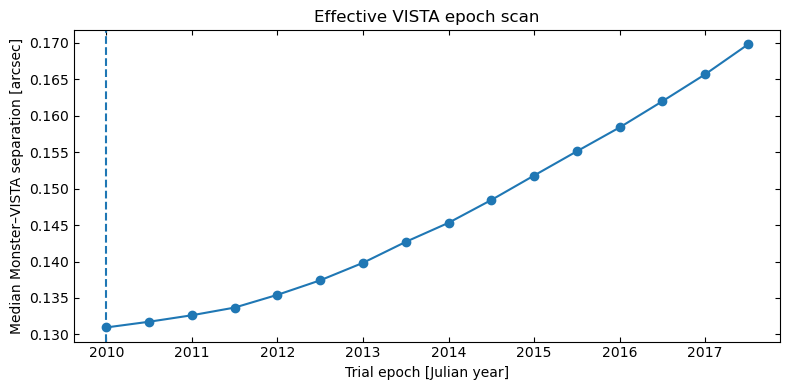

In [18]:
# ----------------------------
# Settings for the epoch scan
# ----------------------------
epoch_grid = np.arange(2010.0, 2018.0, 0.5)     # adjust if you want broader/narrower
scan_radius = 1.0 * u.arcsec                    # loose radius for scan
scan_iso_sep = 1.0 * u.arcsec                   # same isolation idea as main notebook
max_mon_per_shard = 5000                        # speed control

def monster_to_trial_epoch(mon_tbl, mjd_target):
    """Propagate Monster positions to target epoch using PM only."""
    ra0  = np.asarray(mon_tbl["coord_ra"], float)
    dec0 = np.asarray(mon_tbl["coord_dec"], float)
    pmra = np.asarray(mon_tbl["pm_ra"], float)
    pmde = np.asarray(mon_tbl["pm_dec"], float)
    ep   = np.asarray(mon_tbl["epoch"], float)

    keep = (
        np.isfinite(ra0) & np.isfinite(dec0) &
        np.isfinite(pmra) & np.isfinite(pmde) &
        np.isfinite(ep)
    )
    mon = mon_tbl[keep]

    ra0  = np.asarray(mon["coord_ra"], float)
    dec0 = np.asarray(mon["coord_dec"], float)
    pmra = np.asarray(mon["pm_ra"], float)
    pmde = np.asarray(mon["pm_dec"], float)
    ep   = np.asarray(mon["epoch"], float)

    mjd0 = float(np.nanmedian(ep))
    dt = (mjd_target - mjd0) / 365.25

    cosd = np.cos(dec0)
    good = np.abs(cosd) > 1e-12
    mon = mon[good]
    ra0, dec0, pmra, pmde = ra0[good], dec0[good], pmra[good], pmde[good]

    ra1  = ra0  + (pmra * dt) / np.cos(dec0)   # pm_ra = mu_alpha*
    dec1 = dec0 + (pmde * dt)

    ok = np.isfinite(ra1) & np.isfinite(dec1)
    mon = mon[ok]
    cM = SkyCoord(ra=ra1[ok] * u.rad, dec=dec1[ok] * u.rad)
    return cM, mon

def mutual_nn_match(cA, cB, radius):
    idxB, sepAB, _ = match_coordinates_sky(cA, cB)
    idxA, sepBA, _ = match_coordinates_sky(cB, cA)
    a = np.arange(len(cA))
    ok = (sepAB < radius) & (idxA[idxB] == a)
    return ok, idxB, sepAB

def isolate_mask(cM, min_sep):
    _, sep2, _ = match_coordinates_sky(cM, cM, nthneighbor=2)
    return sep2 > min_sep

scan_summary = []

for trial_epoch in epoch_grid:
    mjd_trial = Time(trial_epoch, format="jyear").mjd

    seps_all = []
    nmatch_all = 0

    for shard_id in htm7_ids:
        mon_full = Table.read(monster_path_template.format(id=shard_id))

        need = [
            "id", "coord_ra", "coord_dec",
            "epoch", "pm_ra", "pm_dec"
        ]
        need = [c for c in need if c in mon_full.colnames]
        mon = mon_full[need]

        # Optional speed limit per shard
        if len(mon) > max_mon_per_shard:
            mon = mon[:max_mon_per_shard]

        # Local VISTA cut using Monster native coords
        ra_deg  = np.degrees(np.asarray(mon["coord_ra"], float))
        dec_deg = np.degrees(np.asarray(mon["coord_dec"], float))
        m_v = local_vista_cut(ra_deg, dec_deg)

        vista_loc = vista[m_v]
        cV = vis_coords[m_v]

        if len(vista_loc) == 0 or len(mon) == 0:
            continue

        # Propagate Monster to trial epoch
        cM, mon_use = monster_to_trial_epoch(mon, mjd_trial)
        if len(cM) == 0:
            continue

        # Apply Monster-side isolation
        iso = isolate_mask(cM, min_sep=scan_iso_sep)
        cM_i = cM[iso]

        if len(cM_i) == 0:
            continue

        # Mutual nearest-neighbour match
        ok, idxV, sep = mutual_nn_match(cM_i, cV, radius=scan_radius)
        sep_use = sep[ok].to(u.arcsec).value

        if len(sep_use) > 0:
            seps_all.append(sep_use)
            nmatch_all += len(sep_use)

    if nmatch_all > 0:
        seps_all = np.concatenate(seps_all)
        med = np.nanmedian(seps_all)
        nmad = 1.4826 * np.nanmedian(np.abs(seps_all - med))
    else:
        med = np.nan
        nmad = np.nan

    scan_summary.append((trial_epoch, nmatch_all, med, nmad))
    print(f"epoch={trial_epoch:6.2f}   matches={nmatch_all:7d}   median_sep={med:7.4f}\"   NMAD={nmad:7.4f}\"")

scan_summary = np.array(
    scan_summary,
    dtype=[("epoch", float), ("nmatch", int), ("median_sep", float), ("nmad_sep", float)]
)

# Best epoch = smallest median separation
good = np.isfinite(scan_summary["median_sep"])
best = scan_summary[good][np.argmin(scan_summary["median_sep"][good])]

VIDEO_EPOCH_JYEAR = float(best["epoch"])
MJD_VIDEO = Time(VIDEO_EPOCH_JYEAR, format="jyear").mjd

print("\nBest effective VISTA epoch:")
print(f"VIDEO_EPOCH_JYEAR = {VIDEO_EPOCH_JYEAR:.2f}")
print(f"MJD_VIDEO         = {MJD_VIDEO:.2f}")

# Optional plot
plt.figure(figsize=(8, 4))
plt.plot(scan_summary["epoch"], scan_summary["median_sep"], marker="o")
plt.axvline(VIDEO_EPOCH_JYEAR, ls="--")
plt.xlabel("Trial epoch [Julian year]")
plt.ylabel("Median Monster–VISTA separation [arcsec]")
plt.title("Effective VISTA epoch scan")
plt.tick_params(direction="in", top=True, right=True)
plt.tight_layout()
plt.show()

### Configuration

In [19]:
# Effective epoch for VIDEO positions in the DP1/CDFS tests.
print("VIDEO_EPOCH_JYEAR =", VIDEO_EPOCH_JYEAR, " -> MJD =", MJD_VIDEO)

# Matching parameters
MATCH_RADIUS = 0.5 * u.arcsec          # mutual NN radius
ISO_MIN_SEP = 1.0 * u.arcsec           # Gold: Monster-side isolation (2nd NN > ISO_MIN_SEP)
VISTA_MARGIN_DEG = 0.6                 # local VISTA cut margin around each shard footprint

VIDEO_EPOCH_JYEAR = 2010.0  -> MJD = 55197.0


### Define LSST AFW schema

I start from a minimal schema (includes `id` and `coord`), then add:

- Fluxes (u, g, r, i, z, y, j, h, ks, y2, z2) and errors  
- Astrometric metadata (epoch, PM, parallax)  
- Matching QA (`vista_match_grade`, `vista_sep2010_arcsec`)

In [20]:
schema = afwTable.SimpleTable.makeMinimalSchema()

# Add fluxes
for band in ["u","g","r","i","z","y","j","h","ks","y2","z2"]:
    schema.addField(f"{band}_flux", type="D", units="nJy")
    schema.addField(f"{band}_fluxErr", type="D", units="nJy")

# Add astrometric metadata
schema.addField("coord_raErr", type="D", units="rad")
schema.addField("coord_decErr", type="D", units="rad")
schema.addField("epoch", type="D", units="d")
schema.addField("pm_ra", type="D", units="rad/yr")
schema.addField("pm_dec", type="D", units="rad/yr")
schema.addField("pm_raErr", type="D", units="rad/yr")
schema.addField("pm_decErr", type="D", units="rad/yr")
schema.addField("parallax", type="D", units="rad")
schema.addField("parallaxErr", type="D", units="rad")

# Match QA (Gold-only)
schema.addField("vista_sep2010_arcsec", type="D", units="arcsec")

print("Schema field count:", len(schema.getNames()))


Schema field count: 35


### Build Monster–VISTA

Algorithm per shard:
1. Read Monster HTM7 shard
2. Make a local sky cut in VISTA to speed up matching
3. Propagate Monster coordinates to VIDEO effective epoch (2010.0 here) using PM-only
4. **Gold** matches: mutual nearest neighbour within 0.5″
5. **Gold** matches: Gold + Monster-side isolation (2nd neighbour > 1″)
6. Attach VISTA fluxes to Monster rows; keep Monster astrometry
7. Write AFW `SimpleCatalog` FITS shard to `outdir/`

In [21]:
def local_vista_cut(ra_deg, dec_deg, margin_deg=VISTA_MARGIN_DEG):
    ra_min, ra_max = np.nanmin(ra_deg) - margin_deg, np.nanmax(ra_deg) + margin_deg
    de_min, de_max = np.nanmin(dec_deg) - margin_deg, np.nanmax(dec_deg) + margin_deg
    m = (vista["RA2000"] > ra_min) & (vista["RA2000"] < ra_max) & (vista["DEC2000"] > de_min) & (vista["DEC2000"] < de_max)
    # drop NaNs
    m &= np.isfinite(vista["RA2000"]) & np.isfinite(vista["DEC2000"])
    return m

def monster_to_mjd_pm_only(mon_tbl, mjd_target):
    """Propagate Monster positions to target epoch using PM-only (pm_ra is mu_alpha*), units rad/yr."""
    ra0  = np.asarray(mon_tbl["coord_ra"], float)
    dec0 = np.asarray(mon_tbl["coord_dec"], float)
    pmra = np.asarray(mon_tbl["pm_ra"], float)
    pmde = np.asarray(mon_tbl["pm_dec"], float)
    ep   = np.asarray(mon_tbl["epoch"], float)

    keep = np.isfinite(ra0) & np.isfinite(dec0) & np.isfinite(pmra) & np.isfinite(pmde) & np.isfinite(ep)
    mon = mon_tbl[keep]

    ra0  = np.asarray(mon["coord_ra"], float)
    dec0 = np.asarray(mon["coord_dec"], float)
    pmra = np.asarray(mon["pm_ra"], float)
    pmde = np.asarray(mon["pm_dec"], float)
    ep   = np.asarray(mon["epoch"], float)

    mjd0 = float(np.nanmedian(ep))  # ~57388.5 (Gaia epoch ~2016)
    dt = (mjd_target - mjd0) / 365.25

    cosd = np.cos(dec0)
    good = np.abs(cosd) > 1e-12
    mon = mon[good]
    ra0, dec0, pmra, pmde = ra0[good], dec0[good], pmra[good], pmde[good]

    ra1  = ra0  + (pmra * dt) / np.cos(dec0)  # pmra is mu_alpha*
    dec1 = dec0 + (pmde * dt)

    ok = np.isfinite(ra1) & np.isfinite(dec1)
    mon = mon[ok]
    cM = SkyCoord(ra=ra1[ok]*u.rad, dec=dec1[ok]*u.rad)
    return cM, mon

def mutual_nn_match(cA, cB, radius=MATCH_RADIUS):
    idxB, sepAB, _ = match_coordinates_sky(cA, cB)  # A -> B
    idxA, sepBA, _ = match_coordinates_sky(cB, cA)  # B -> A
    a = np.arange(len(cA))
    ok = (sepAB < radius) & (idxA[idxB] == a)
    return ok, idxB, sepAB

def isolate_mask(cM, min_sep=ISO_MIN_SEP):
    _, sep2, _ = match_coordinates_sky(cM, cM, nthneighbor=2)
    return sep2 > min_sep

# Build all shards
# Build all shards (Gold-only: isolation + mutual NN at VIDEO_EPOCH_JYEAR)
all_separations = {}
for shard_id in htm7_ids:
    mon_full = Table.read(monster_path_template.format(id=shard_id))

    # Keep only columns we need (robust to missing flux cols)
    need = [
        "id","coord_ra","coord_dec",
        "coord_raErr","coord_decErr",
        "epoch","pm_ra","pm_dec",
        "pm_raErr","pm_decErr",
        "parallax","parallaxErr"
    ] + list(monster_rename.keys())
    need = [c for c in need if c in mon_full.colnames]
    mon = mon_full[need]

    # Rename Monster flux columns
    for old, new in monster_rename.items():
        if old in mon.colnames:
            mon.rename_column(old, new)

    # Local VISTA selection
    ra_deg  = np.degrees(np.asarray(mon["coord_ra"], float))
    dec_deg = np.degrees(np.asarray(mon["coord_dec"], float))
    m_v = local_vista_cut(ra_deg, dec_deg)

    vista_loc = vista[m_v]
    cV = vis_coords[m_v]

    # Propagate Monster -> VIDEO epoch (2010) for matching
    cM, mon_use = monster_to_mjd_pm_only(mon, MJD_VIDEO)

    # Output arrays aligned to ORIGINAL mon
    N = len(mon)
    sep2010 = np.full(N, np.nan, dtype=float)

    vista_selected = Table()
    for col in vista_cols:
        vista_selected[col] = np.full(N, np.nan, dtype=float)

    # Map mon_use rows back to mon indices via id
    id_to_index = {int(mon["id"][i]): i for i in range(N)}
    mon_use_idx = np.array([id_to_index[int(x)] for x in mon_use["id"]], dtype=int)

    # Gold matches: isolation + mutual NN
    iso = isolate_mask(cM, min_sep=ISO_MIN_SEP)
    cM_i = cM[iso]
    mon_i_idx = mon_use_idx[iso]

    ok_g, idxV_g, sep_g = mutual_nn_match(cM_i, cV, radius=MATCH_RADIUS)
    if ok_g.sum() > 0:
       all_separations[shard_id] = sep_g[ok_g].to(u.arcsec).value  # <-- add this

       ii = mon_i_idx[ok_g]
       jj = idxV_g[ok_g]
       sep2010[ii] = sep_g[ok_g].to(u.arcsec).value
       for col in vista_cols:
           vista_selected[col][ii] = np.asarray(vista_loc[col][jj], float)
    else:
       all_separations[shard_id] = np.array([], dtype=float)
   
    # Rename VISTA flux columns into LSST names
    vista_selected.rename_columns(list(vista_rename.keys()), list(vista_rename.values()))

    # QA table
    qa = Table()
    qa["vista_sep2010_arcsec"] = sep2010

    # Merge
    final = hstack([mon, vista_selected, qa], join_type="exact")

    # Write AFW catalog
    catalog = afwTable.SimpleCatalog(schema)
    coordKey = catalog.getCoordKey()

    # Pre-compute keys for speed
    keys = {}
    for name in final.colnames:
        if name in ("id", "coord_ra", "coord_dec"):
            continue
        if name in catalog.schema:
            keys[name] = catalog.schema.find(name).key

    for row in final:
        rec = catalog.addNew()

        # id
        if np.isfinite(row["id"]):
            rec.setId(int(row["id"]))

        # coord from Monster (native epoch)
        if np.isfinite(row["coord_ra"]) and np.isfinite(row["coord_dec"]):
            rec.set(coordKey, SpherePoint(float(row["coord_ra"]), float(row["coord_dec"]), radians))

        # scalar fields
        for col, key in keys.items():
            val = row[col]
            if val is None or isinstance(val, str):
                continue
            try:
                if not np.isfinite(val):
                    continue
            except TypeError:
                continue

            if isinstance(key, (afwTable.KeyI, afwTable.KeyL)):
                rec.set(key, int(val))
            else:
                rec.set(key, float(val))

    outname = f"{outdir}/{shard_id}.fits"
    catalog.writeFits(outname)

    ng = int(np.sum(np.isfinite(sep2010)))
    print(f"✅ Shard {shard_id}: rows={len(catalog)}  gold_matches={ng}  -> {outname}")


✅ Shard 147048: rows=1705  gold_matches=1227  -> data/video_cdfs/the_monster_20250219_vista/147048.fits
✅ Shard 147049: rows=1670  gold_matches=1171  -> data/video_cdfs/the_monster_20250219_vista/147049.fits
✅ Shard 147051: rows=1624  gold_matches=1251  -> data/video_cdfs/the_monster_20250219_vista/147051.fits
✅ Shard 147172: rows=1759  gold_matches=1334  -> data/video_cdfs/the_monster_20250219_vista/147172.fits
✅ Shard 147174: rows=1779  gold_matches=1221  -> data/video_cdfs/the_monster_20250219_vista/147174.fits
✅ Shard 147175: rows=1720  gold_matches=1277  -> data/video_cdfs/the_monster_20250219_vista/147175.fits
✅ Shard 147028: rows=1634  gold_matches=474  -> data/video_cdfs/the_monster_20250219_vista/147028.fits
✅ Shard 147042: rows=1789  gold_matches=0  -> data/video_cdfs/the_monster_20250219_vista/147042.fits
✅ Shard 147050: rows=1638  gold_matches=288  -> data/video_cdfs/the_monster_20250219_vista/147050.fits
✅ Shard 147052: rows=1618  gold_matches=0  -> data/video_cdfs/the_mon

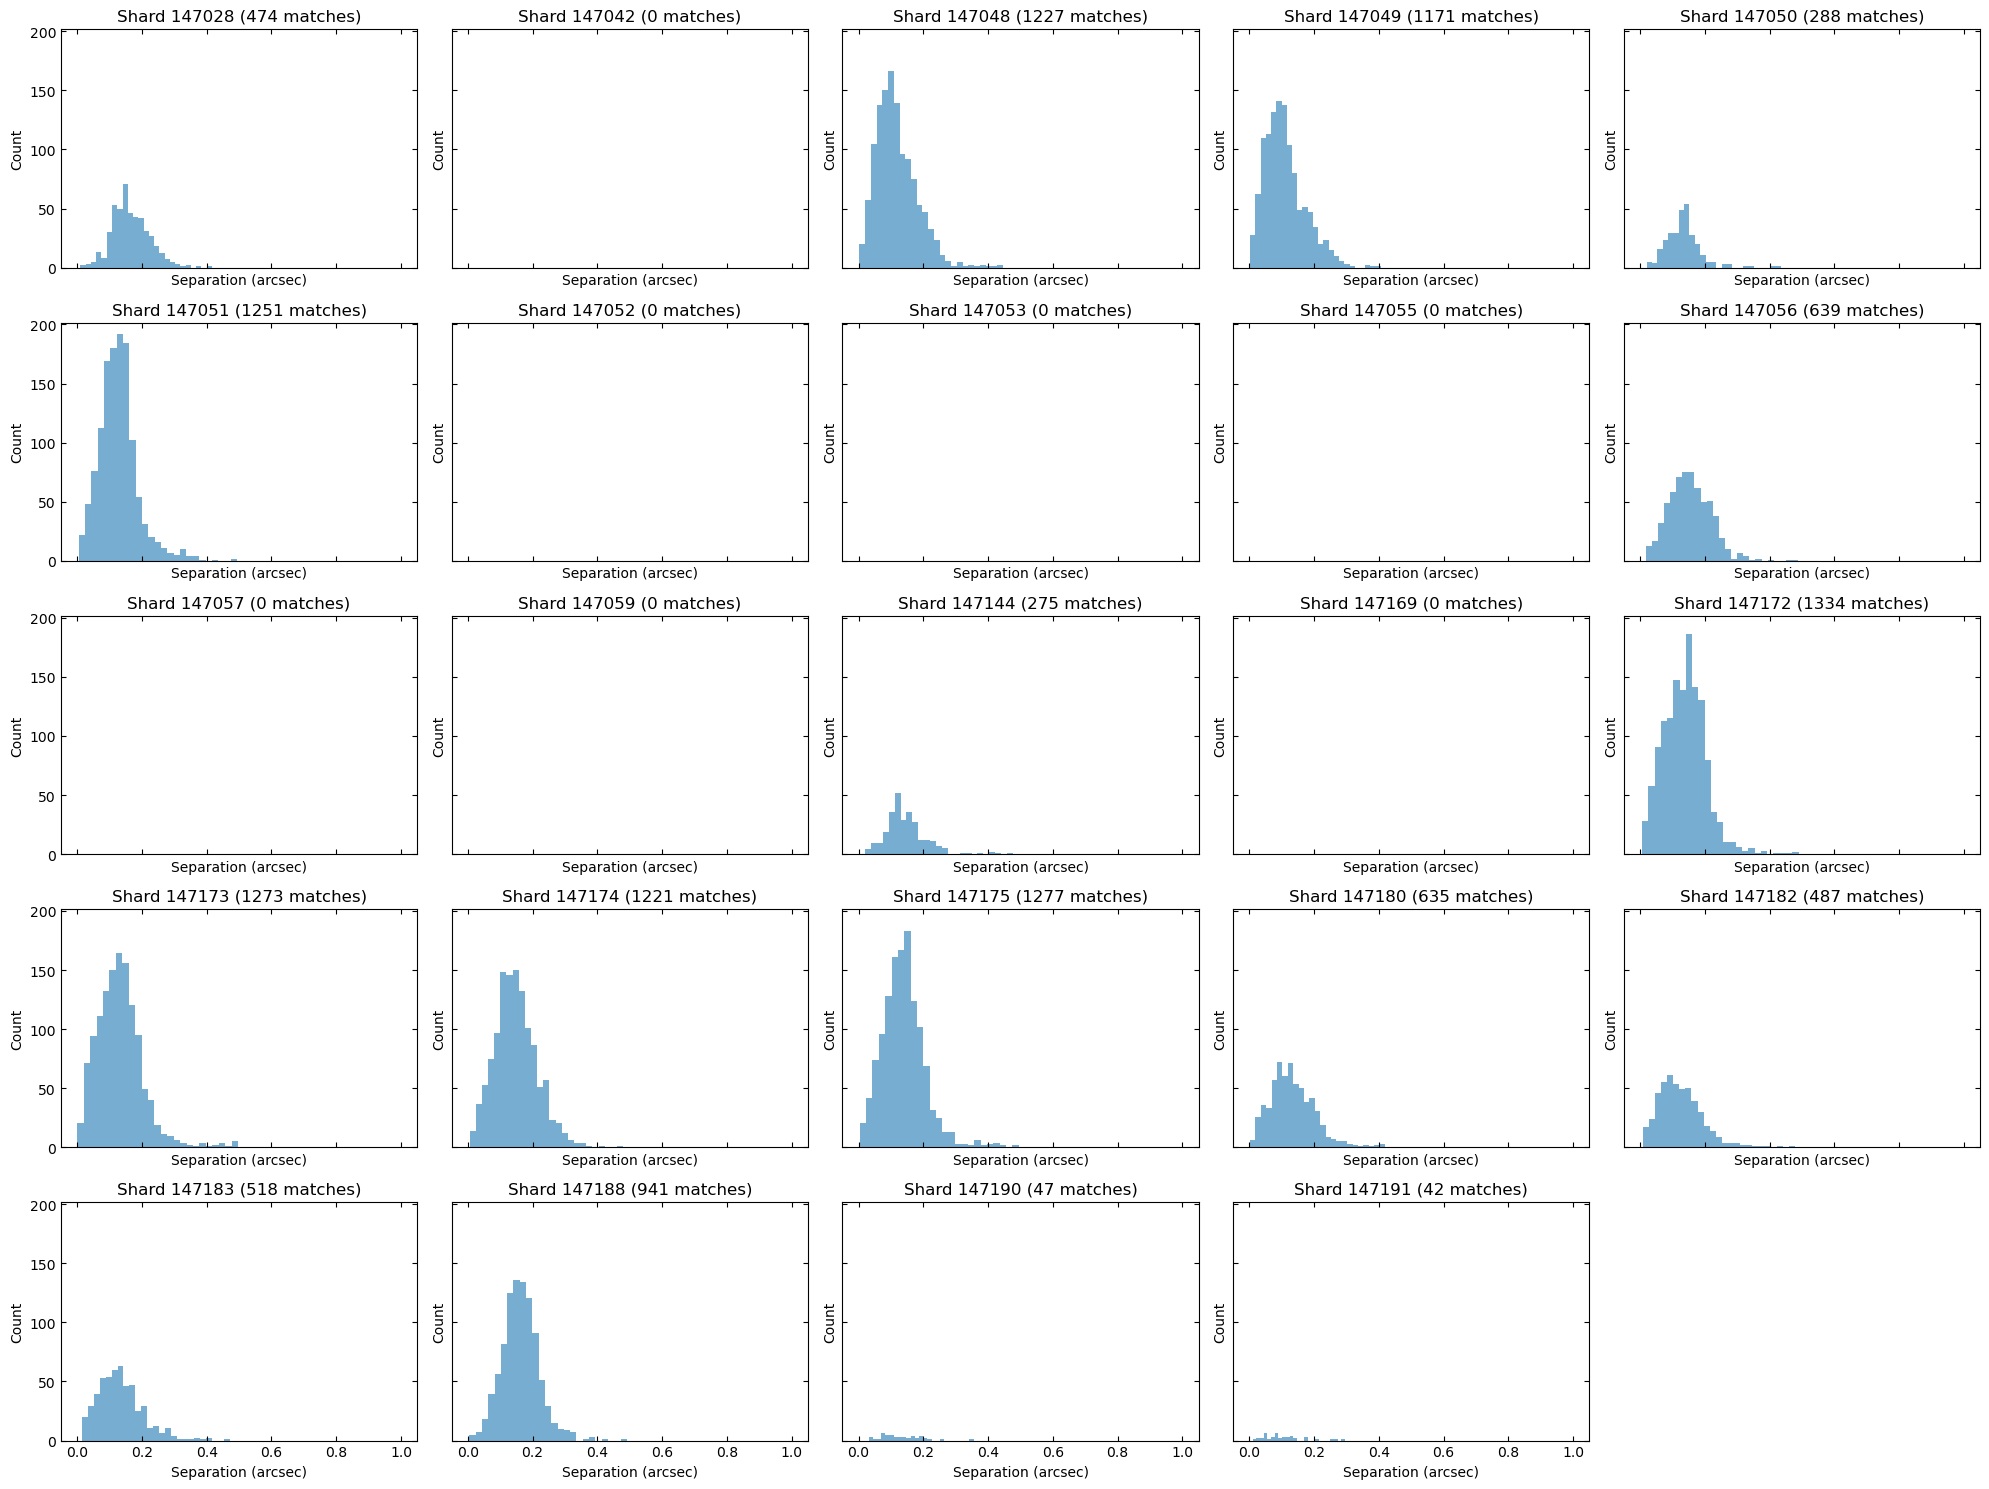

In [22]:
# Expect: all_separations = {htm7_id: np.array([...])} in arcsec
if "all_separations" not in globals() or len(all_separations) == 0:
    raise RuntimeError("all_separations is missing/empty.")

# Sort by shard id for consistent layout
items = sorted(all_separations.items(), key=lambda kv: kv[0])

n_shards = len(items)
ncols = 5
nrows = int(np.ceil(n_shards / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(20, 3*nrows), sharex=True, sharey=True)
axes = np.atleast_1d(axes).ravel()

for ax, (htm_id, sep_arcsec) in zip(axes, items):
    sep_arcsec = np.asarray(sep_arcsec, float)
    sep_arcsec = sep_arcsec[np.isfinite(sep_arcsec)]
    ax.hist(sep_arcsec, bins=25, alpha=0.6)
    ax.set_title(f"Shard {htm_id} ({len(sep_arcsec)} matches)")
    ax.set_xlabel('Separation (arcsec)')
    ax.set_ylabel('Count')
    ax.tick_params(direction="in", top=True, right=True)

# Hide empty panels
for ax in axes[n_shards:]:
    ax.axis("off")

plt.tight_layout()
plt.show()